## Odds ratio analysis of gene loss and duplication

Testing whether the odds that genes in an orthogroup are missing, in single copy, or in multiple copies differs significantly between orb-weavers and non-orb-weavers

#### import modules

In [1]:
import os
import sys
import pandas as pd
from importlib import reload


# Set the working directory to the scripts directory
# This is necessary to ensure that the script can find the src directory
# and any other relative paths correctly.
scripts = os.path.abspath('')

# Ensure the src directory is in the Python path
src_path = os.path.abspath(os.path.join(scripts, '..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

# Define paths to data and results directories
data = os.path.join(scripts, "..", "data")
results = os.path.join(scripts, "..", "results")


# Import the odds_ratio_test
import odds_ratio_test as ort
reload(ort)

/Users/calvin/anaconda3/envs/orb-selection/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'odds_ratio_test' from '/Users/calvin/orb-selection/src/odds_ratio_test.py'>

In [2]:
%load_ext autoreload
%autoreload 2

#### specify input files

In [3]:
genecount_csv = f"{data}/N5.GeneCount.tsv"
orb_list_filename = f"{data}/orbweavers-list.txt"
hog_node_genes_tsv = f"{data}/N5.tsv"

Testing for loss of genes first, using occupancy threshold of 75 (same as HyPhy analysis)

Also using a maximum occupancy of N-3 = 95 so there can be some meaningful comparison of loss between the test groups.

In [4]:
loss_results_dir = f"{results}/loss-test"

In [5]:
loss_lt_75_95 = ort.odds_ratio_test(
    orb_list_filename,
    hog_node_genes_tsv,
    "loss",
    genecount_csv=genecount_csv,
    occupancy_threshold=75,
    max_occ=95, 
    alpha=0.01,
    alternative="less",
    species_of_interest="Uloborus_diversus",
)

98 species total, 44 foreground, 54 background

LAUNCHING BOOTSTRAPPING TEST

** Maximum occupancy set to 95 **

** Minimum occupancy set to 75 **

Counting bootstrapped distributions in which statistics
derived from randomly assigned test groups are SMALLER
than the true distribution's statistics (left-tailed)...



100%|██████████| 10000/10000 [00:54<00:00, 184.04it/s]


Bootstrapping counter for MEAN: 0
Bootstrapping counter for STD DEV: 10000
Bootstrapping counter for SKEW: 8556

Filtering log odds ratio results df for occupancy >= 75, <= 95
and log odds ratio threshold [-1.71766239  1.72045358]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for loss (left-tailed)
with minimum occupancy *75* and maximum occupancy *95* 

Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 2627
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.6300388762633876
True standard deviation: 1.5374700980875577
True skew: 0.14789325395694103

** BOOTSTRAPPING P-VALUES ** 

Probability t

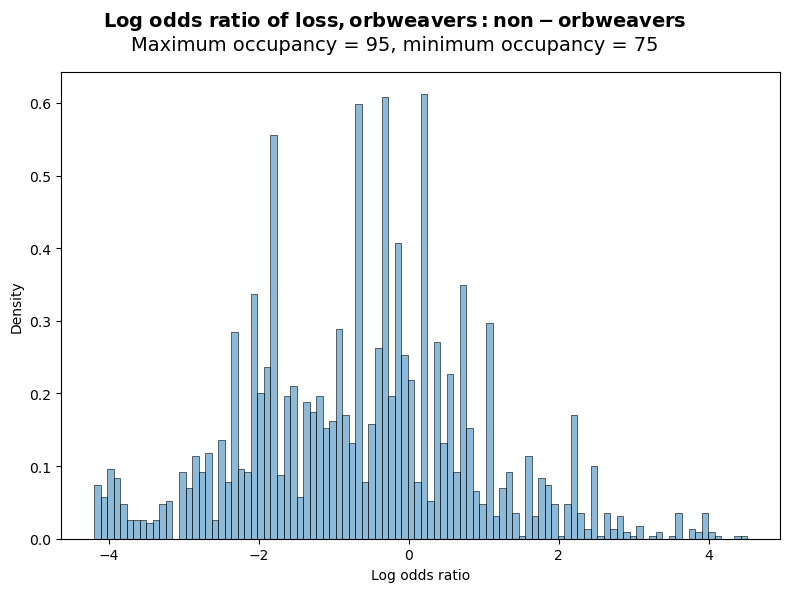

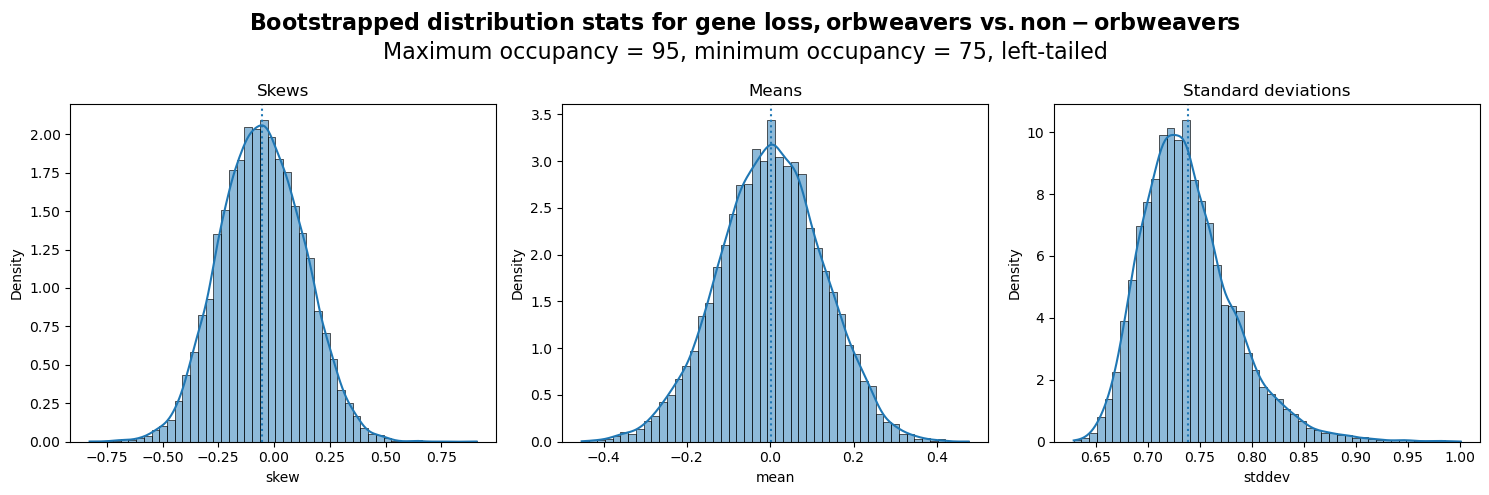

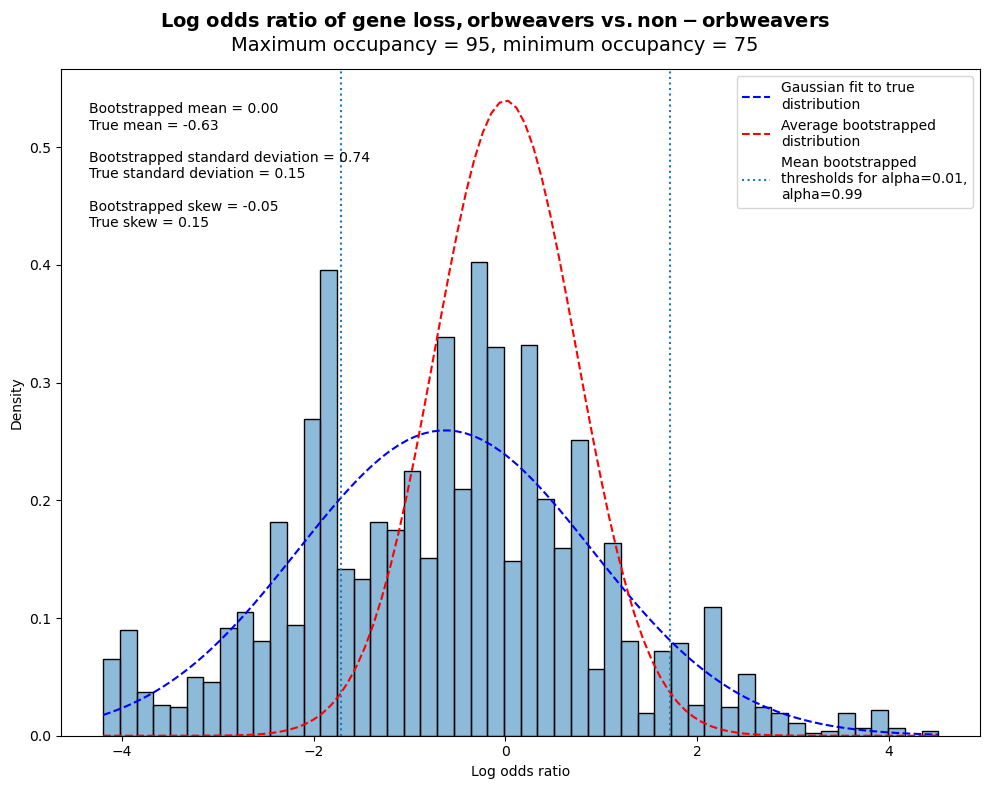

In [17]:
loss_lt_75_95.save_results_files(loss_results_dir, fg_name='orbweavers', bg_name='non-orbweavers')

In [7]:
loss_rt_75_95 = ort.odds_ratio_test(
    orb_list_filename,
    hog_node_genes_tsv,
    "loss",
    genecount_csv=genecount_csv,
    occupancy_threshold=75,
    max_occ=95, 
    alpha=0.01,
    alternative="greater",
    species_of_interest="Uloborus_diversus",
)

98 species total, 44 foreground, 54 background

LAUNCHING BOOTSTRAPPING TEST

** Maximum occupancy set to 95 **

** Minimum occupancy set to 75 **

Counting bootstrapped distributions in which statistics
derived from randomly assigned test groups EXCEED
the true distribution's statistics (right-tailed)...



100%|██████████| 10000/10000 [00:55<00:00, 181.12it/s]



Bootstrapping counter for MEAN: 10000
Bootstrapping counter for STD DEV: 0
Bootstrapping counter for SKEW: 1401

Filtering log odds ratio results df for occupancy >= 75, <= 95
and log odds ratio threshold [-1.71387548  1.71778444]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for loss (right-tailed)
with minimum occupancy *75* and maximum occupancy *95* 

Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 2627
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.6300388762633876
True standard deviation: 1.5374700980875577
True skew: 0.14789325395694103

** BOOTSTRAPPING P-VALUES ** 

Probability 

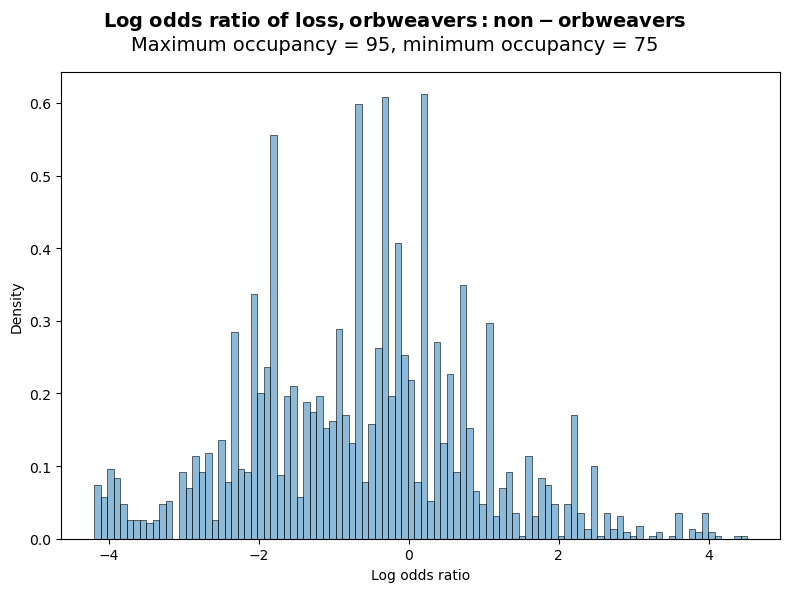

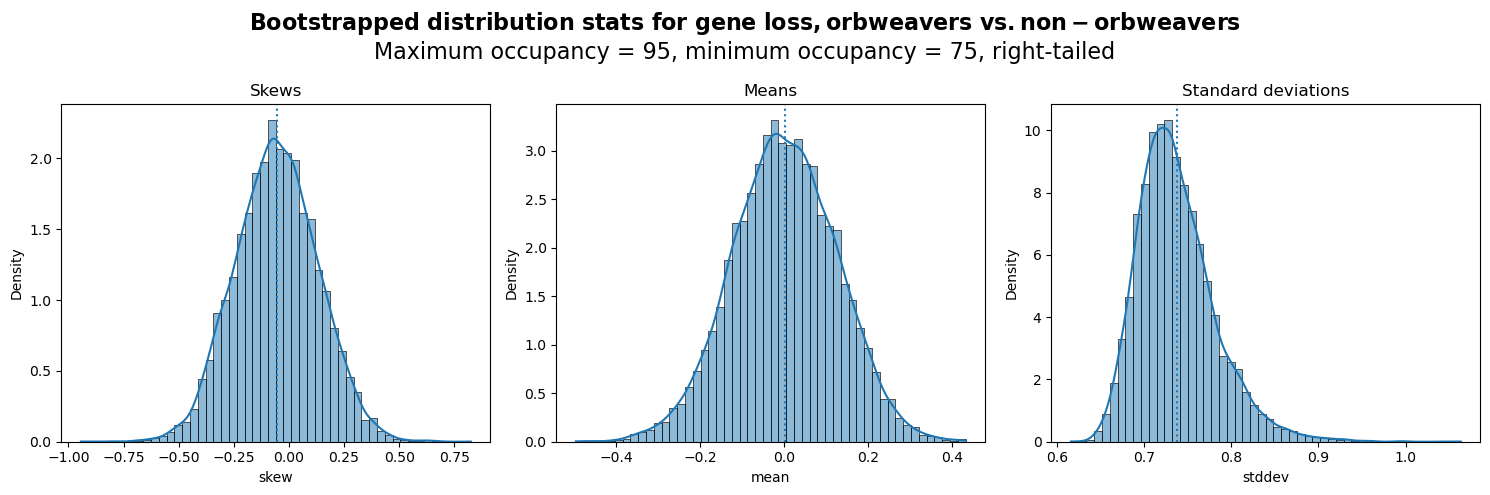

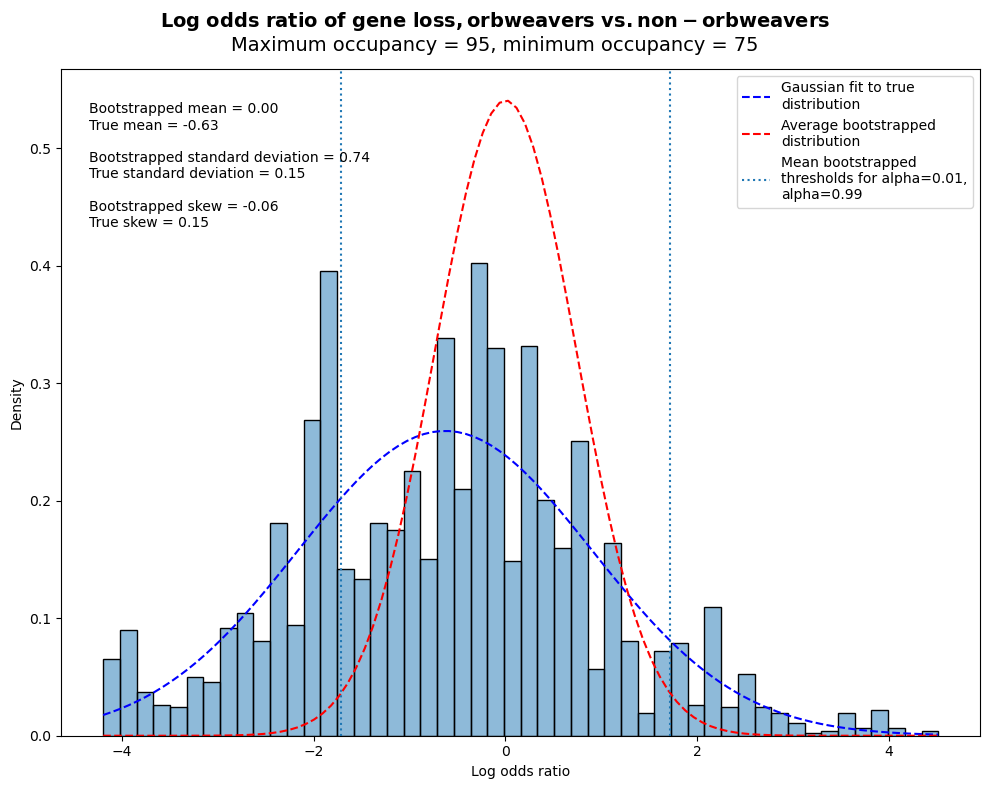

In [18]:
loss_rt_75_95.save_results_files(loss_results_dir, fg_name='orbweavers', bg_name='non-orbweavers')

Testing for duplication of genes, using minimum occupancy threshold of 75, no max occupancy.

In [9]:
dup_results_dir = f"{results}/duplication-test"

In [10]:
dup_lt_75_95 = ort.odds_ratio_test(
    orb_list_filename,
    hog_node_genes_tsv,
    "duplication",
    genecount_csv=genecount_csv,
    occupancy_threshold=75,
    alpha=0.01,
    alternative="less",
    species_of_interest="Uloborus_diversus",
)

98 species total, 44 foreground, 54 background

LAUNCHING BOOTSTRAPPING TEST

** Minimum occupancy set to 75 **

Counting bootstrapped distributions in which statistics
derived from randomly assigned test groups are SMALLER
than the true distribution's statistics (left-tailed)...



100%|██████████| 10000/10000 [00:49<00:00, 203.41it/s]


Bootstrapping counter for MEAN: 1857
Bootstrapping counter for STD DEV: 10000
Bootstrapping counter for SKEW: 8804

Filtering log odds ratio results df for occupancy >= 75, <= 98
and log odds ratio threshold [-1.45440415  1.4549452 ]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for duplication (left-tailed)
with minimum occupancy *75* and maximum occupancy *no* 

Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 5233
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.04746996232571979
True standard deviation: 0.8929220790292889
True skew: 0.059449503392817564

** BOOTSTRAPPING P-VALUES ** 

P

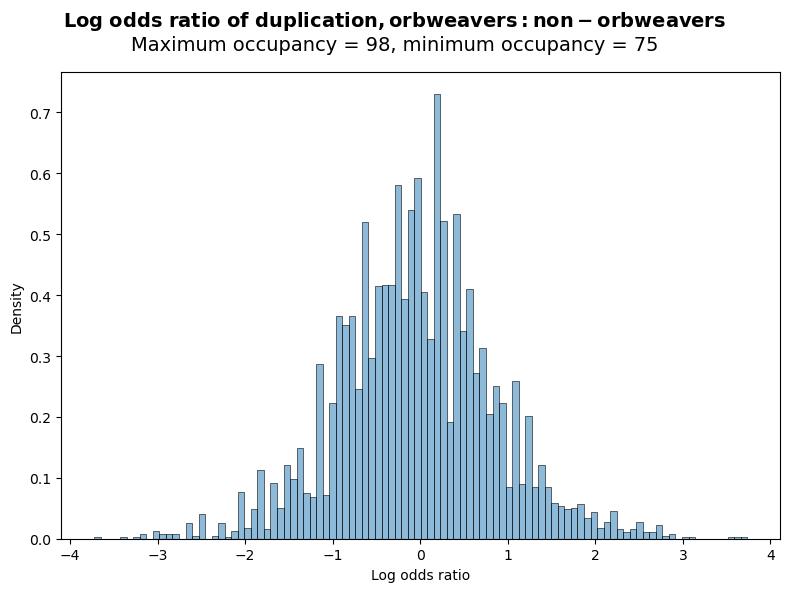

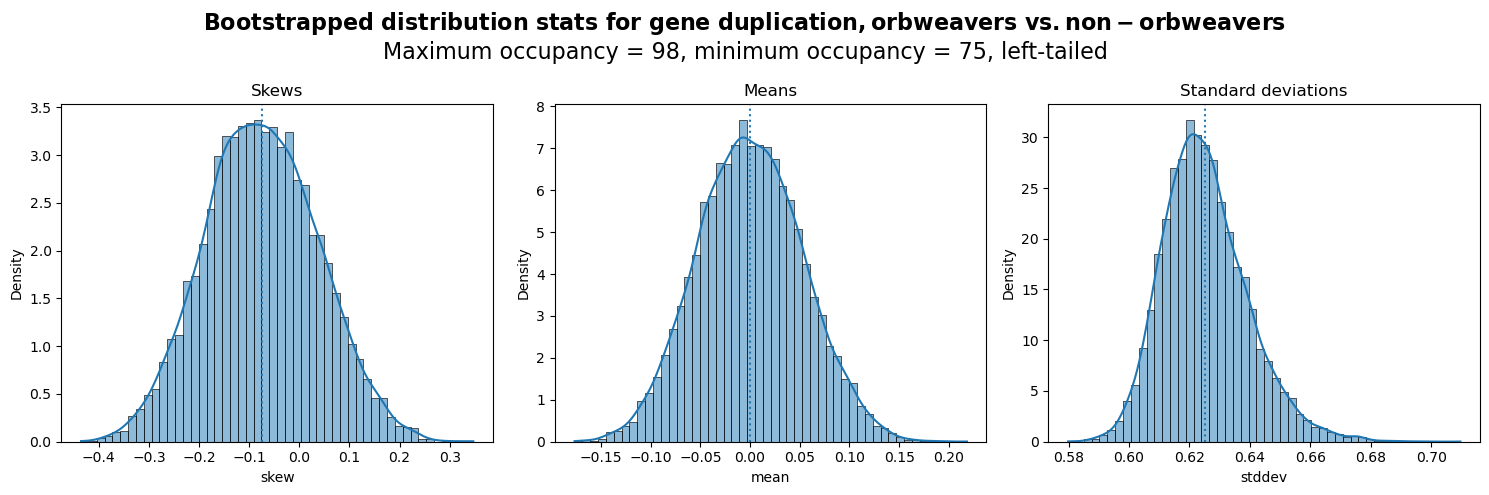

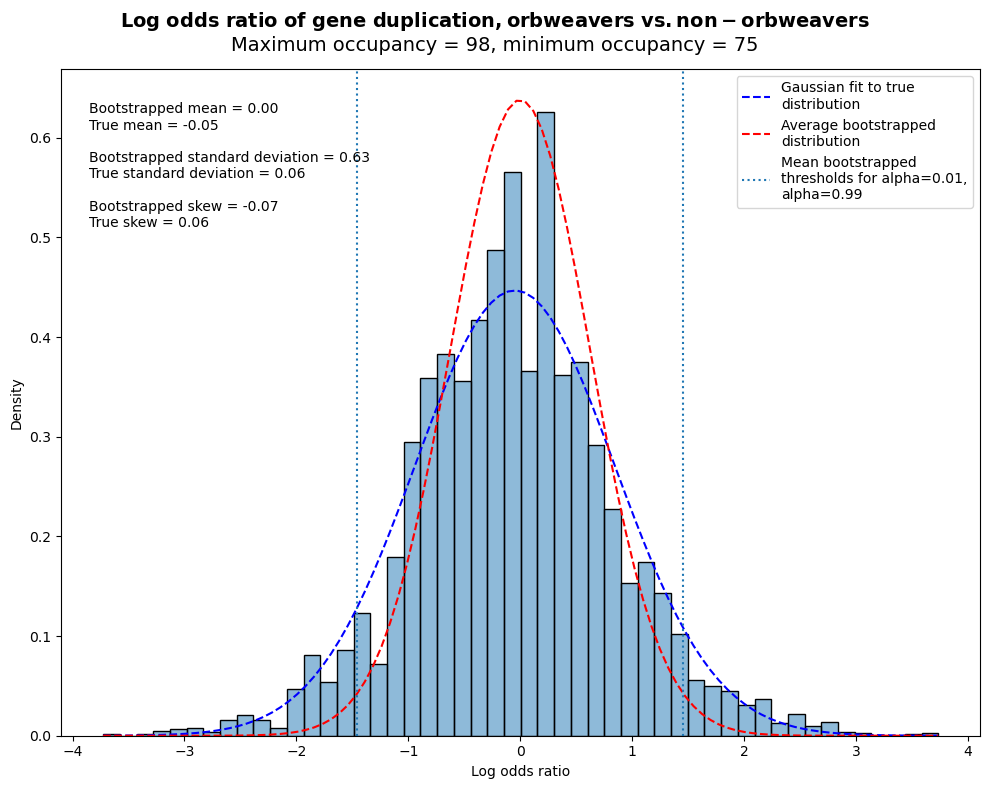

In [19]:
dup_lt_75_95.save_results_files(dup_results_dir, fg_name='orbweavers', bg_name='non-orbweavers')

In [12]:
dup_rt_75_95 = ort.odds_ratio_test(
    orb_list_filename,
    hog_node_genes_tsv,
    "duplication",
    genecount_csv=genecount_csv,
    occupancy_threshold=75,
    alpha=0.01,
    alternative="greater",
    species_of_interest="Uloborus_diversus",
)

98 species total, 44 foreground, 54 background

LAUNCHING BOOTSTRAPPING TEST

** Minimum occupancy set to 75 **

Counting bootstrapped distributions in which statistics
derived from randomly assigned test groups EXCEED
the true distribution's statistics (right-tailed)...



100%|██████████| 10000/10000 [00:49<00:00, 200.33it/s]


Bootstrapping counter for MEAN: 8240
Bootstrapping counter for STD DEV: 0
Bootstrapping counter for SKEW: 1178

Filtering log odds ratio results df for occupancy >= 75, <= 98
and log odds ratio threshold [-1.45322553  1.45582282]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for duplication (right-tailed)
with minimum occupancy *75* and maximum occupancy *no* 

Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 5233
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.04746996232571979
True standard deviation: 0.8929220790292889
True skew: 0.059449503392817564

** BOOTSTRAPPING P-VALUES ** 

Prob

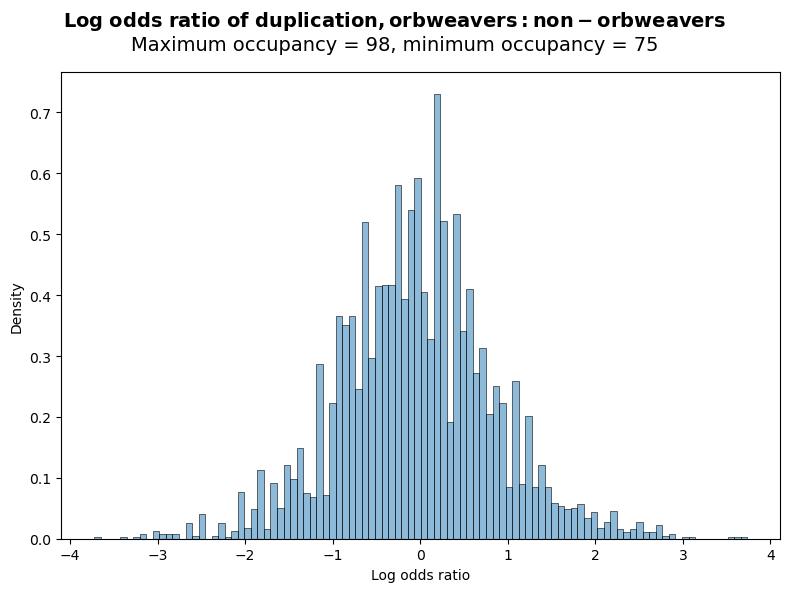

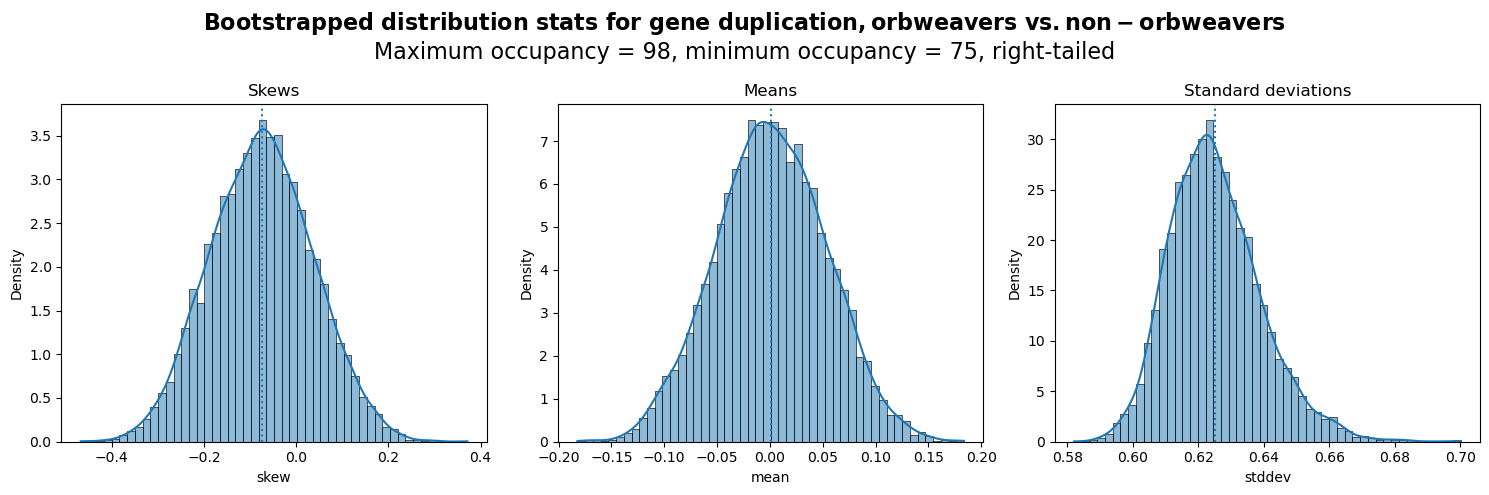

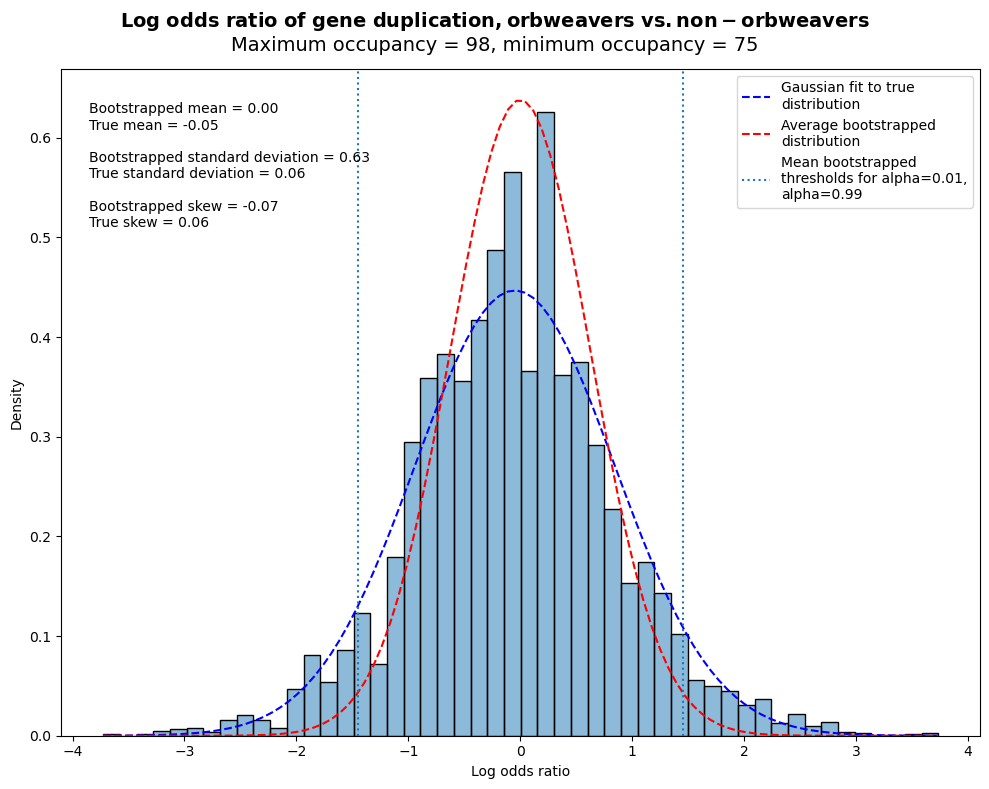

In [20]:
dup_rt_75_95.save_results_files(dup_results_dir, fg_name='orbweavers', bg_name='non-orbweavers')